# **Stage 4: Exploratory Data Analysis**

## Step 1 — Setup & Data Loading
Import libraries and load the processed datasets from Stage 3.

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
import os

# Adjust this path if your notebook is in a different folder!
BASE_PATH = "../3. Data Collection and Dataset Preparation/Clean_data/"

# Load the freshly cleaned datasets
df = pd.read_csv(os.path.join(BASE_PATH, "processed_emails.csv"), dtype=str)
train_df = pd.read_csv(os.path.join(BASE_PATH, "train_safe.csv"), dtype=str)
test_df = pd.read_csv(os.path.join(BASE_PATH, "test_mixed.csv"), dtype=str)

# Ensure text columns don't have NaNs and calculate length
df['text'] = df['text'].fillna('')
df['length'] = df['text'].apply(len)

# Convert labels back to integers for plotting/modeling
df['label'] = df['label'].astype(int)
train_df['label'] = train_df['label'].astype(int)
test_df['label'] = test_df['label'].astype(int)

print(f"✅ Clean Data Loaded! Total Rows: {len(df)}")

✅ Clean Data Loaded! Total Rows: 531588


## Step 2 — Class Distribution
Visualize the 28:1 class imbalance between normal and phishing emails.

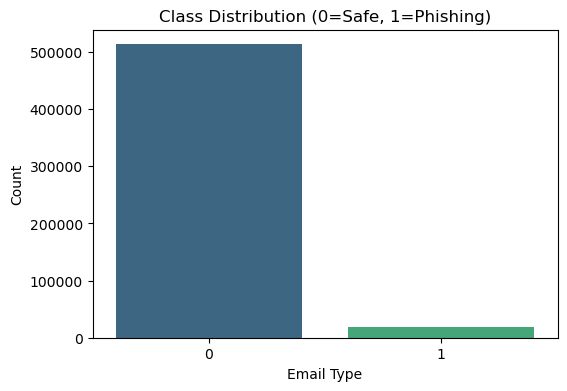

Dataset breakdown:
label
0    513547
1     18041
Name: count, dtype: int64


In [18]:
# --- Cell 2: Class Distribution ---
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df, hue='label', palette='viridis', legend=False)
plt.title('Class Distribution (0=Safe, 1=Phishing)')
plt.xlabel('Email Type')
plt.ylabel('Count')
plt.show()

print("Dataset breakdown:")
print(df['label'].value_counts())

## Step 3 — Email Length Analysis
Compare character length distributions between safe and phishing emails after outlier filtering.

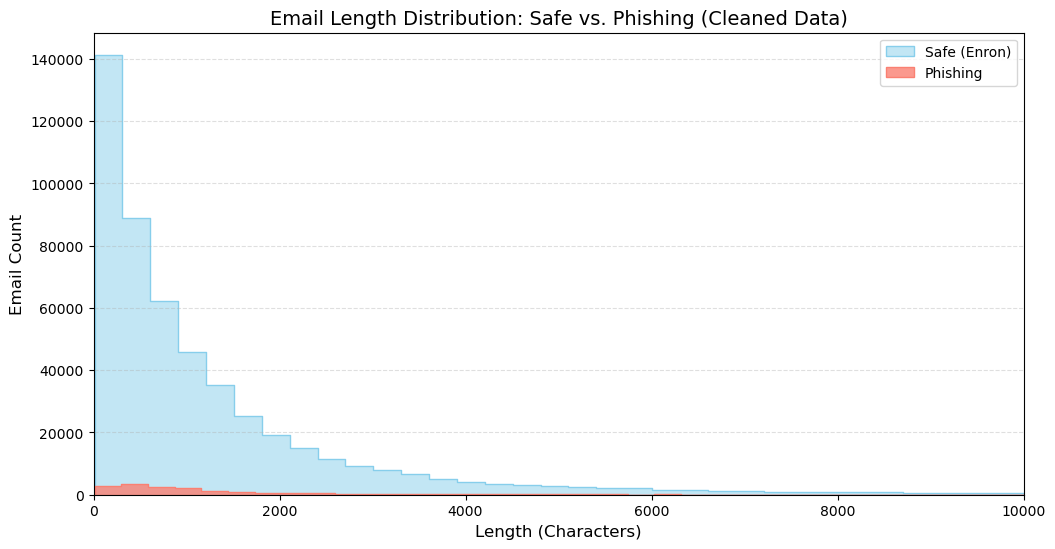


--- New Statistical Insights ---
              mean    50%      max
label                             
0      1456.991683  728.0  29987.0
1      1701.096447  897.0  28672.0


In [19]:
# --- Cell 3: Email Length Analysis ---
plt.figure(figsize=(12, 6))

# Since extreme outliers are gone, we can use a standard histplot without log scales flattening it
sns.histplot(df[df['label']==0]['length'], color='skyblue', label='Safe (Enron)', 
             bins=100, element="step", fill=True, alpha=0.5)

sns.histplot(df[df['label']==1]['length'], color='salmon', label='Phishing', 
             bins=100, element="step", fill=True, alpha=0.8)

plt.title('Email Length Distribution: Safe vs. Phishing (Cleaned Data)', fontsize=14)
plt.xlabel('Length (Characters)', fontsize=12)
plt.ylabel('Email Count', fontsize=12)

# Zoom in on the most common lengths
plt.xlim(0, 10000) 
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

print("\n--- New Statistical Insights ---")
print(df.groupby('label')['length'].describe()[['mean', '50%', 'max']])

## Step 4 — Semantic Word Clouds
Generate word clouds for normal and phishing emails to confirm the vocabulary split: corporate scheduling terms vs. urgency and financial keywords.

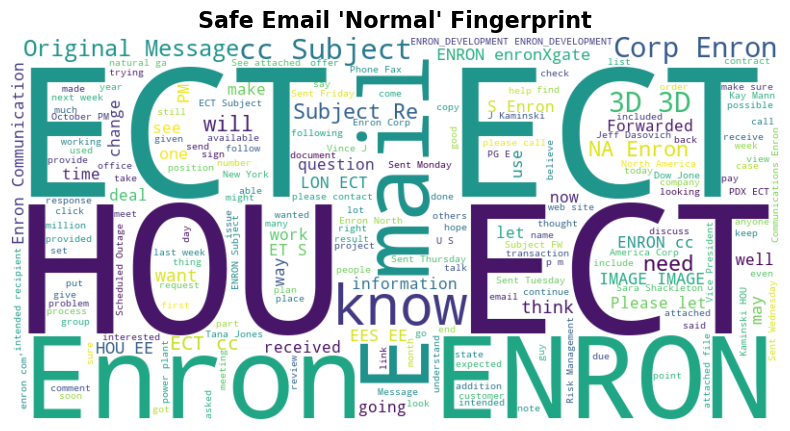

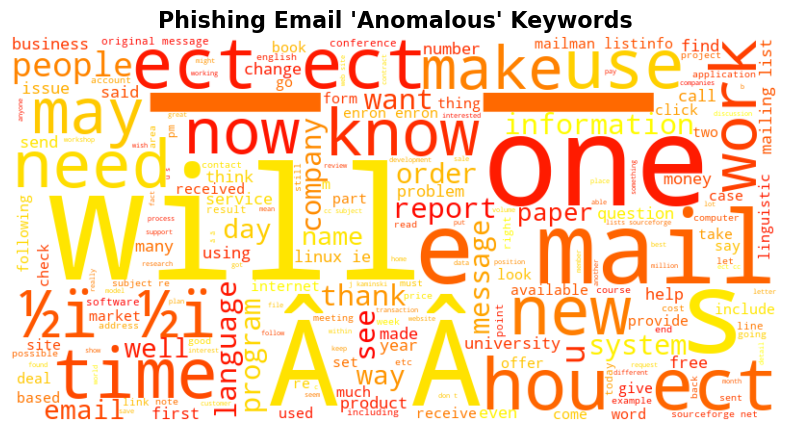

In [20]:
# --- Cell 4: Semantic Word Clouds ---
def plot_wordcloud(label, title, cmap):
    # Grab the text for the specific class
    text = " ".join(df[df['label'] == label]['text'].astype(str))
    
    # Generate the cloud
    wc = WordCloud(width=800, height=400, background_color='white', colormap=cmap).generate(text)
    
    # Plotting
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis("off")
    plt.title(title, fontsize=16, fontweight='bold')
    plt.show()

# Run the visual analysis
plot_wordcloud(0, "Safe Email 'Normal' Fingerprint", 'viridis')
plot_wordcloud(1, "Phishing Email 'Anomalous' Keywords", 'autumn')

## Step 5 — Baseline Model: TF-IDF + Isolation Forest
Train a TF-IDF (5,000 features) + Isolation Forest model as an unsupervised baseline. Confirms the accuracy trap: 85% overall accuracy but 0% phishing recall — justifying the deep learning approach.

Vectorizing text using TF-IDF (Max 5,000 features)...
Training Baseline Isolation Forest (Unsupervised ML)...
Evaluating on the Mixed Battlefield Test Set...

 STAGE 4: BASELINE PERFORMANCE SUMMARY
              precision    recall  f1-score   support

           0     0.8506    1.0000    0.9193    102710
           1     0.0000    0.0000    0.0000     18041

    accuracy                         0.8506    120751
   macro avg     0.4253    0.5000    0.4596    120751
weighted avg     0.7235    0.8506    0.7819    120751



C:\Users\bar_t\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\bar_t\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\bar_t\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


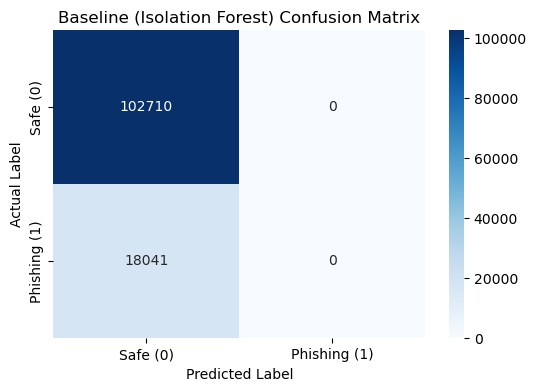

In [22]:
# --- Cell 5: Baseline Isolation Forest (Unsupervised Benchmark) ---
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("Vectorizing text using TF-IDF (Max 5,000 features)...")
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')

# Fit ONLY on the training data
X_train = vectorizer.fit_transform(train_df['text'].astype(str))
X_test = vectorizer.transform(test_df['text'].astype(str))

print("Training Baseline Isolation Forest (Unsupervised ML)...")
# Isolation Forest maps what "Normal" looks like. It doesn't even look at the labels!
model = IsolationForest(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train) 

print("Evaluating on the Mixed Battlefield Test Set...")
# Isolation Forest returns 1 for Normal (Safe) and -1 for Anomalies (Phishing)
raw_preds = model.predict(X_test)

# Convert predictions to match our project's labels (1 -> 0 Safe, -1 -> 1 Phishing)
preds = [0 if x == 1 else 1 for x in raw_preds]

print("\n" + "="*50)
print(" STAGE 4: BASELINE PERFORMANCE SUMMARY")
print("="*50)
print(classification_report(test_df['label'], preds, digits=4))

# Let's visualize where it failed (The Confusion Matrix)
plt.figure(figsize=(6,4))
cm = confusion_matrix(test_df['label'], preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Safe (0)', 'Phishing (1)'], 
            yticklabels=['Safe (0)', 'Phishing (1)'])
plt.title('Baseline (Isolation Forest) Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()